In [9]:
import itertools
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import cm
import json
import seaborn as sns
import plot_utils
import glob

In [10]:
sns.set_theme(context='notebook',style = 'ticks',
              palette='muted', font='sans', 
              font_scale=1, color_codes=True, rc=None)

In [11]:
pocam_2 = 26
hem_2 = 51
emitter_2 = 'LMG405'
batch_2 = 2


In [12]:
pocam_1 = 11
hem_1 = 13
emitter_1 = 'LMG405'
batch_1 = 1

In [13]:
file_path_1 = f'../output/batch{batch_1:01d}/pocam_{pocam_1:03d}/hem_{hem_1:02d}/{emitter_1}/isotropy.json'
file_path_2 = f'../output/batch{batch_2:01d}/pocam_{pocam_2:03d}/hem_{hem_2:02d}/{emitter_2}/isotropy.json'

In [14]:
with open(file_path_1, "r") as f:
    data_1 = json.load(f)
    
with open(file_path_2, "r") as f:
    data_2 = json.load(f)

In [15]:
def truncate_colormap(cmap, minval=0.0, maxval=0.8, n=256):
    return LinearSegmentedColormap.from_list(
        f"trunc({cmap.name},{minval},{maxval})",
        cmap(np.linspace(minval, maxval, n))
    )

In [24]:
cmap_trunc = truncate_colormap(cm.RdBu_r, 0.2, 0.8)

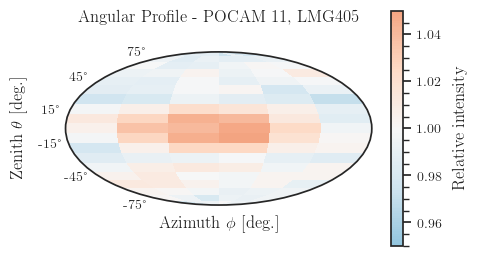

In [17]:
data = data_1
d = data["meas_data"][0]
Z = np.array(d["z_values"])

x = np.linspace(d["x_min"], d["x_max"], d["x_bins"]+1)
y = np.linspace(d["y_min"], d["y_max"], d["y_bins"]+1)

fig = plt.figure(figsize=plot_utils.set_size('wide', fraction=0.7, subplots=(1, 1)))
ax = fig.add_subplot(111, projection="mollweide")

c = ax.pcolormesh(x, y, Z, cmap = cmap_trunc, vmin = 0.95, vmax = 1.05)

ax.set_title(f'Angular Profile - POCAM {pocam_1}, {emitter_1}', y = 1.3)
ax.set_xticks(np.radians(np.arange(-150,200, 60)))
ax.set_yticks(np.radians(np.arange(-75,80, 30)))
fig.colorbar(c, ax=ax, label="Relative intensity")
ax.set_xlabel(r'Azimuth $\phi$ [deg.]')
ax.set_ylabel(r'Zenith $\theta$ [deg.]')

plt.savefig(f'plots/png/ang_prof_pocam_{pocam_1}_{emitter_1}.png')
plt.savefig(f'plots/pdf/ang_prof_pocam_{pocam_1}_{emitter_1}.pdf')

In [18]:
import healpy as hp

Text(0, 0.5, 'Zenith $\\theta$ [deg.]')

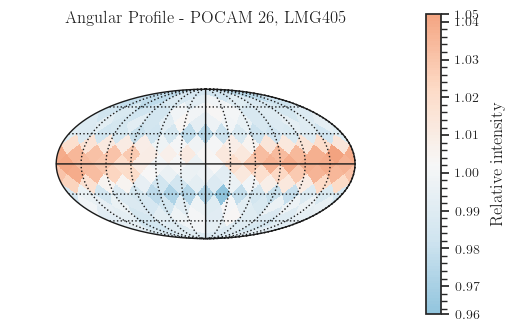

In [19]:
data = data_2
NSIDE = 2**2
NPIX = hp.nside2npix(NSIDE)

vec = hp.ang2vec(np.pi / 2, np.pi * 3 / 4)
ipix_disc = hp.query_strip(NSIDE, np.radians(0), np.radians(150))
deg = np.degrees(hp.pix2ang(nside=NSIDE, ipix=ipix_disc))

d = data["meas_data"][0]
Z = np.array(d["z_values"])

fig = plt.figure(figsize=plot_utils.set_size('wide', fraction=0.7, subplots=(1, 1)))
hp.mollview(
    Z,
    fig=fig.number,
    sub=(1, 1, 1),
    title='',
    cmap=cmap_trunc,
    cbar=False  
)

hp.graticule()

# get axis + image
ax = fig.gca()
im = ax.get_images()[0]   # this is the mappable for colorbar

# custom colorbar
cbar = fig.colorbar(im, ax=ax, orientation='vertical')
cbar.set_label("Relative intensity")

ax.set_title(f'Angular Profile - POCAM {pocam_2}, {emitter_2}', y = 1.3)
ax.set_xticks(np.radians(np.arange(-150,200, 60)))
ax.set_yticks(np.radians(np.arange(-75,80, 30)))
# fig.colorbar(c, ax=ax, label="Relative intensity")
ax.set_xlabel(r'Azimuth $\phi$ [deg.]')
ax.set_ylabel(r'Zenith $\theta$ [deg.]')

# plt.savefig(f'plots/png/ang_prof_pocam_{pocam}_{emitter}.png')
# plt.savefig(f'plots/pdf/ang_prof_pocam_{pocam}_{emitter}.pdf')

In [20]:
from matplotlib.ticker import NullLocator, FixedLocator, FuncFormatter

NSIDE = 2**2
d = data_1["meas_data"][0]
Z = np.array(d["z_values"])
x = np.linspace(d["x_min"], d["x_max"], d["x_bins"]+1)
y = np.linspace(d["y_min"], d["y_max"], d["y_bins"]+1)

d_2 = data_2["meas_data"][0]
Z_2 = np.array(d_2["z_values"])

vmin, vmax = 0.95, 1.05

# ── Convert HEALPix map to 2D lon/lat grid ─────────────────────────────────
xsize = 800  # resolution of the reprojected grid
lon = np.linspace(-np.pi, np.pi, xsize)
lat = np.linspace(-np.pi/2, np.pi/2, xsize//2)
LON, LAT = np.meshgrid(lon, lat)

# Convert lat/lon grid to HEALPix pixel indices and sample the map
theta_hp = np.pi/2 - LAT          # colatitude
phi_hp   = LON + np.pi            # [0, 2pi]
ipix     = hp.ang2pix(NSIDE, theta_hp, phi_hp)
Z_2_grid = Z_2[ipix]

In [21]:
x_ticks = np.radians(np.arange(-150, 180, 60))
y_ticks = np.radians(np.arange(-75, 80, 30))
y_ticks_label = np.arange(-75, 80, 30)

def setup_ax(ax):
    ax.xaxis.set_major_locator(FixedLocator(x_ticks))
    ax.yaxis.set_major_locator(FixedLocator(y_ticks))
    ax.xaxis.set_minor_locator(NullLocator())
    ax.yaxis.set_minor_locator(NullLocator())
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{round(np.degrees(x)):.0f}$^\circ$'))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{round(np.degrees(x)):.0f}$^\circ$'))
    ax.set_xlabel(r'Azimuth $\phi$ [deg]')
    if ax == ax1:
        ax.set_ylabel(r'Zenith $\theta$ [deg]')
    ax.grid(True)
    # force x tick labels visible — Mollweide hides them by default
    for label in ax.xaxis.get_ticklabels():
        label.set_visible(True)

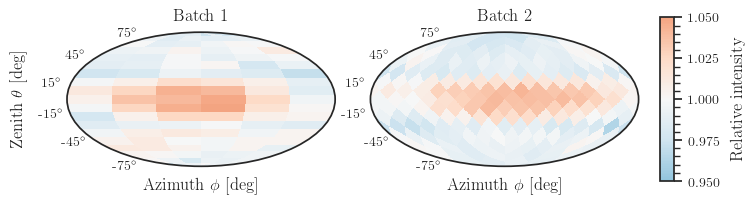

In [22]:
fig = plt.figure(figsize=plot_utils.set_size('wide', fraction=1.0, subplots=(1, 2)))
# ── Panel 1: pcolormesh mollweide ──────────────────────────────────────────
ax1 = fig.add_axes([0.05, 0.1, 0.38, 0.75], projection='mollweide')
c1 = ax1.pcolormesh(x, y, Z, cmap=cmap_trunc, vmin=vmin, vmax=vmax)
setup_ax(ax1)
ax1.set_title('Batch 1', y = 1.2, size = 12)

# ── Panel 2: HEALPix reprojected to pcolormesh mollweide ──────────────────
ax2 = fig.add_axes([0.48, 0.1, 0.38, 0.75], projection='mollweide')
ax2.pcolormesh(LON, LAT, Z_2_grid, cmap=cmap_trunc, vmin=vmin, vmax=vmax)
setup_ax(ax2)
ax2.set_title('Batch 2', y = 1.2, size = 12)

# ── Single shared colorbar ─────────────────────────────────────────────────
cax = fig.add_axes([0.89, 0.1, 0.02, 0.75])
fig.colorbar(c1, cax=cax, label="Relative intensity")

plt.savefig(f'plots/png/ang_prof_pocam_{pocam_1}_batch1_{pocam_2}_batch2_{emitter_1}.png', bbox_inches='tight')
plt.savefig(f'plots/pdf/ang_prof_pocam_{pocam_1}_batch1_{pocam_2}_batch2_{emitter_2}.pdf', bbox_inches='tight')

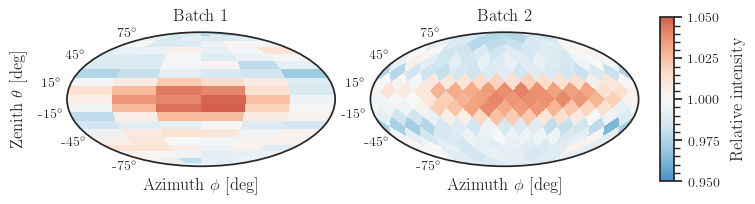

In [26]:
fig = plt.figure(figsize=plot_utils.set_size('wide', fraction=1.0, subplots=(1, 2)))

# ── Panel 1: pcolormesh mollweide ──────────────────────────────────────────
ax1 = fig.add_axes([0.05, 0.1, 0.38, 0.75], projection='mollweide')
c1 = ax1.pcolormesh(x, y, Z, cmap=cmap_trunc, vmin=vmin, vmax=vmax, rasterized=True)
ax1.set_title('Batch 1', y=1.2, size=12)
ax1.xaxis.set_tick_params(labelbottom=True)
setup_ax(ax1)

# ── Panel 2: HEALPix reprojected to pcolormesh mollweide ──────────────────
ax2 = fig.add_axes([0.48, 0.1, 0.38, 0.75], projection='mollweide')
ax2.pcolormesh(LON, LAT, Z_2_grid, cmap=cmap_trunc, vmin=vmin, vmax=vmax, rasterized=True)
ax2.set_title('Batch 2', y=1.2, size=12)
ax2.xaxis.set_tick_params(labelbottom=True)
setup_ax(ax2)

# ── Single shared colorbar ─────────────────────────────────────────────────
cax = fig.add_axes([0.89, 0.1, 0.02, 0.75])
fig.colorbar(c1, cax=cax, label="Relative intensity")
ax1.set_xticklabels([f'{int(np.degrees(t))}°' for t in ax1.get_xticks()])
ax2.set_xticklabels([f'{int(np.degrees(t))}°' for t in ax2.get_xticks()])

plt.savefig(f'plots/png/ang_prof_pocam_{pocam_1}_batch1_{pocam_2}_batch2_{emitter_1}.png',
            bbox_inches='tight')
plt.savefig(f'plots/pdf/ang_prof_pocam_{pocam_1}_batch1_{pocam_2}_batch2_{emitter_2}.pdf',
            bbox_inches='tight')


In [27]:
#plot all the intensities of POCAM
path_b1 = '../output/batch1/pocam_*/hem_*/LMG405/isotropy.json'
path_b2 = '../output/batch2/pocam_*/hem_*/LMG405/isotropy.json'
files_b1 = glob.glob(path_b1)
files_b2 = glob.glob(path_b2)

In [28]:
isotropy_b1 = np.zeros((len(files_b1),2))
for i, f in enumerate(files_b1):
    with open(f, "r") as file:
        data = json.load(file)
        isotropy_b1[i,0] = int(data["device_uid"][-3:])
        isotropy_b1[i,1] = data["meas_data"][1]["value"]

#sort isotropy from highest to lowest and move both columns accordingly
isotropy_b1 =  isotropy_b1[isotropy_b1[:,1].argsort()[::-1]]

isotropy_b1 = isotropy_b1[::2]

In [29]:
isotropy_b2 = np.zeros((len(files_b2),2))
for i, f in enumerate(files_b2):
    with open(f, "r") as file:
        data = json.load(file)
        isotropy_b2[i,0] = int(data["device_uid"][-3:])
        isotropy_b2[i,1] = data["meas_data"][1]["value"]

#sort isotropy from highest to lowest and move both columns accordingly
isotropy_b2 =  isotropy_b2[isotropy_b2[:,1].argsort()[::-1]]
#take only the entrie 0,2,4,....
isotropy_b2 = isotropy_b2[::2]

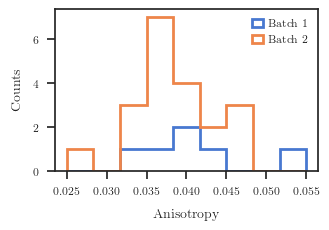

In [30]:
bins= np.linspace(0.025, .055, 10)
fig, ax = plt.subplots(figsize=plot_utils.set_size('colums', fraction=1, subplots=(1, 1)))
ax.hist(isotropy_b1[:,1], bins=bins, histtype = 'step', lw = 2, label='Batch 1')
ax.hist(isotropy_b2[:,1], bins=bins, histtype = 'step', lw =2, label='Batch 2')
ax.legend()
ax.set_xlabel('Anisotropy')
ax.set_ylabel('Counts')

plt.savefig(f'plots/png/isotropy_histogram_batch1_batch2.png', bbox_inches='tight')
plt.savefig(f'plots/pdf/isotropy_histogram_batch1_batch2.pdf', bbox_inches='tight')

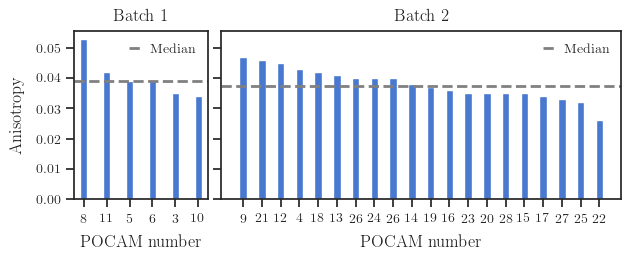

In [31]:
#plot the anisotrpy in descending order put the x axislabels as the POCAM number
# the second plot should be double in width as the first one
med_b1 = np.median(isotropy_b2[:,1])
med_b2 = np.median(isotropy_b2[:,1])

w = 0.3
fig, (ax1,ax2) = plt.subplots(1,2,figsize=plot_utils.set_size('wide', fraction=1, subplots=(1, 2)), 
                              gridspec_kw={'width_ratios': [1, 3]}, sharey=True)
ax1.bar(np.arange(len(isotropy_b1)), isotropy_b1[:,1], width=w)
ax1.axhline(np.median(isotropy_b1[:,1]), color='grey', linestyle='--', label=f'Median')
ax2.bar(np.arange(len(isotropy_b2)), isotropy_b2[:,1], width=w+0.1)
ax2.axhline(np.median(isotropy_b2[:,1]), color='grey', linestyle='--', label=f'Median')
ax1.set_xlabel('POCAM number')
ax1.set_ylabel('Anisotropy')
ax2.set_xlabel('POCAM number')

ax1.set_xticks(np.arange(len(isotropy_b1)))
ax1.set_xticklabels(isotropy_b1[:,0].astype(int))
ax2.set_xticks(np.arange(len(isotropy_b2)))
ax2.set_xticklabels(isotropy_b2[:,0].astype(int))
#adjust the spacing between the two plots
plt.subplots_adjust(wspace=0.05)
ax1.set_title('Batch 1', y = 1.15, size = 12)
ax2.set_title('Batch 2', y = 1.15, size = 12)

ax1.legend(frameon = False, loc='upper right')
ax2.legend(frameon = False, loc='upper right')

plt.savefig(f'plots/png/anisotropy_pocam_batch1_batch2.png', bbox_inches='tight')
plt.savefig(f'plots/pdf/anisotropy_pocam_batch1_batch2.pdf', bbox_inches='tight')


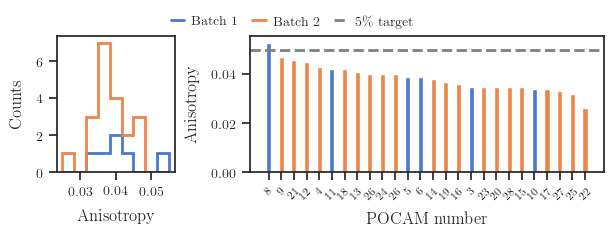

In [34]:
bins = np.linspace(0.025, .055, 10)
w = 0.4

fig = plt.figure(figsize=plot_utils.set_size('wide', fraction=1, ratio = 0.5, subplots=(1, 2)))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 3], wspace=0.32)

ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])

# ── Panel 1: histogram ────────────────────────────────────────────────────
ax0.hist(isotropy_b1[:, 1], bins=bins, histtype='step', lw=2, label='Batch 1', color='C0')
ax0.hist(isotropy_b2[:, 1], bins=bins, histtype='step', lw=2, label='Batch 2', color='C1')
# ax0.legend(frameon=False)
ax0.set_xlabel('Anisotropy')
ax0.set_ylabel('Counts')

# ── Panel 2: combined bar chart, descending order ─────────────────────────
# tag each entry with pocam id, anisotropy value, and batch label
all_entries = (
    [(int(row[0]), row[1], 'Batch 1', 'C0') for row in isotropy_b1] +
    [(int(row[0]), row[1], 'Batch 2', 'C1') for row in isotropy_b2]
)
# sort descending by anisotropy
all_entries.sort(key=lambda x: x[1], reverse=True)

pocam_ids  = [e[0] for e in all_entries]
anisotropy = [e[1] for e in all_entries]
colors     = [e[3] for e in all_entries]

x = np.arange(len(all_entries))
bars = ax1.bar(x, anisotropy, width=w, color=colors)
# ax1.axhline(np.median(np.concatenate([isotropy_b1[:, 1], isotropy_b2[:, 1]])),
#             color='grey', linestyle='--', label='Median')
ax1.axhline(0.05,
            color='grey', linestyle='--', label='5\% target')

ax1.set_xticks(x)
ax1.set_xticklabels(pocam_ids, rotation=45, fontsize=8)
ax1.set_xlabel('POCAM number')
ax1.set_ylabel('Anisotropy')
# ax1.set_title('All POCAMs', y=1.05, size=12)

# manual legend for batch colors
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0],color='C0', label='Batch 1'),
    Line2D([0], [0],color='C1', label='Batch 2'),
    Line2D([0], [0],color='grey', linestyle='--', label='5\% target'),
]
ax1.legend(handles=legend_handles, bbox_to_anchor = (0.5, 1.25), ncols = 3, columnspacing = 1, frameon=False, loc='upper right')

plt.subplots_adjust(wspace=0.3)

plt.savefig('plots/png/isotropy_histogram_batch1_batch2.png', bbox_inches='tight')
plt.savefig('plots/pdf/isotropy_histogram_batch1_batch2.pdf', bbox_inches='tight')